# Portugal salary distribution: grouped public-data fits for monthly earnings

This notebook extracts the public salary-distribution tables from the official **GEP/MTSSS Quadros de Pessoal** chronological Excel workbooks and tests how well several positive-support distributions approximate the published distribution of monthly earnings.

The key constraint is that the public workbooks expose **grouped tables**, not worker-level microdata. That means the notebook fits distributions by **grouped likelihood** on published salary brackets and then validates those fits against the published **median** and **mean earnings by decile**.

## What this notebook is trying to answer

There are two separate questions:

1. Is the public salary distribution consistent with a **Gamma** approximation?
2. If Gamma is not best, which alternatives fit the grouped data better?

To avoid overclaiming, the notebook compares **Gamma**, **Lognormal**, **Weibull**, and **Generalized Gamma**. It also computes a simple **Pareto tail diagnostic** for the top salary brackets, because the top tail is often where smooth body distributions fail.

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pt_salary_gamma_distribution import (
    build_manual_validation_checks,
    build_salary_bin_dataset,
    build_year_totals,
    decile_validation,
    decile_validation_summary,
    deduplicate_brackets,
    deduplicate_summaries,
    download_manifest,
    extract_all_sources,
    fit_year_models,
    gamma_parameter_trend,
    grouped_residuals,
    model_winners,
    optional_microdata_fit,
    pareto_tail_diagnostics,
    validate_against_percentages,
)
from pt_salary_gamma_distribution.fitting import fit_row_to_object

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
PRIVATE_DIR = DATA_DIR / "private"
MANIFEST_PATH = DATA_DIR / "source_manifest.csv"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


The notebook uses a small typed package under `src/pt_salary_gamma_distribution/` so the extraction and fitting logic can be tested separately from the notebook narrative.

## Source manifest and reproducible downloads

The manifest lists the official GEP workbook URLs. Several windows overlap, which is useful because it lets us prefer the latest published version of a year when the same year appears in more than one workbook.

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
sources = download_manifest(manifest, RAW_DIR, overwrite=False)
valid_sources = sources.query("status == 'ok'").copy()

if valid_sources.empty:
    raise RuntimeError("No official sources could be downloaded. Check the manifest or network access.")

sources.to_csv(PROCESSED_DIR / "download_status.csv", index=False)
display(sources[["source_id", "start_year", "end_year", "status", "local_path", "error"]])

,source_id,start_year,end_year,status,local_path,error
0,seriesqp_1999_2009,1999,2009,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
1,seriesqp_2007_2017,2007,2017,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
2,seriesqp_2010_2020,2010,2020,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
3,seriesqp_2011_2021,2011,2021,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
4,seriesqp_2012_2022,2012,2022,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
5,seriesqp_2013_2023,2013,2023,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
6,seriesqp_2014_2024,2014,2024,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,


The main check here is whether every workbook downloads and stays a real spreadsheet rather than an HTML redirect page. In this run the downloads should all be `ok`; if not, the manifest needs an official URL refresh before any statistical work is credible.

## Extract the public grouped tables

The older 1999–2009 workbook contains remuneration context but not the grouped salary-bracket and decile tables needed for grouped likelihood. In practice, the public grouped-distribution window starts in **2007**, using the `q23/q24` structure in the older workbooks and `q32/q33` in the recent ones.

In [3]:
brackets_raw, summaries_raw = extract_all_sources(valid_sources)

source_priority = manifest.set_index("source_id")["end_year"].to_dict()
salary_brackets = deduplicate_brackets(brackets_raw, source_priority)
salary_summaries = deduplicate_summaries(summaries_raw, source_priority)
salary_bins = build_salary_bin_dataset(salary_brackets)
year_totals = build_year_totals(salary_summaries)
percentage_checks = validate_against_percentages(salary_bins)

salary_brackets.to_csv(PROCESSED_DIR / "salary_brackets_raw_long.csv", index=False)
salary_summaries.to_csv(PROCESSED_DIR / "salary_summaries_raw_long.csv", index=False)
salary_bins.to_csv(PROCESSED_DIR / "salary_bins_long.csv", index=False)
year_totals.to_csv(PROCESSED_DIR / "year_totals.csv", index=False)
percentage_checks.to_csv(PROCESSED_DIR / "salary_bin_percentage_checks.csv", index=False)

coverage_summary = pd.DataFrame(
    {
        "dataset": ["salary_brackets", "salary_summaries"],
        "first_year": [int(salary_brackets["year"].min()), int(salary_summaries["year"].min())],
        "last_year": [int(salary_brackets["year"].max()), int(salary_summaries["year"].max())],
        "n_years": [salary_brackets["year"].nunique(), salary_summaries["year"].nunique()],
    }
)
display(coverage_summary)
display(salary_bins.head(12))

,dataset,first_year,last_year,n_years
0,salary_brackets,2007,2024,18
1,salary_summaries,2007,2024,18


,year,bin_label,count,pct,lower,upper,bin_type
0,2007,< RMMG,6255.0,0.290521,0.0,403.00,below_minimum_wage
1,2007,= RMMG,110024.0,5.110198,402.5,403.50,exact_minimum_wage
2,2007,">RMMG e <= 599,99 €",688488.0,31.977661,403.0,599.99,above_minimum_wage_to_threshold
3,2007,"600,00 - 749,99 €",403847.0,18.757164,600.0,749.99,closed_range
4,2007,"750,00 - 999,99 €",347693.0,16.149024,750.0,999.99,closed_range
5,2007,"1 000,00 - 1 499,99 €",298549.0,13.866471,1000.0,1499.99,closed_range
6,2007,"1 500,00 - 2 499,99 €",199371.0,9.260028,1500.0,2499.99,closed_range
7,2007,"2 500,00 - 3 749,99 €",65645.0,3.048962,2500.0,3749.99,closed_range
8,2007,"3 750,00 - 4 999,99 €",19130.0,0.888516,3750.0,4999.99,closed_range
9,2007,"5 000,00 e + euros",14026.0,0.651455,5000.0,inf,open_top


The extraction result matters more than the raw row count. What matters is that the grouped analysis is now explicitly framed as a **2007–2024** public-data exercise, not a 1999–2024 claim. That removes the false precision that came from assuming those earlier years had the same grouped tables.

## Validate against the original workbooks

A parser that "runs" is not enough. This section cross-checks three explicit workbook values directly against the extracted output:

- **2007**: one bracket count from the earliest grouped workbook;
- **2014**: one decile mean from the modern workbook layout;
- **2024**: the most recent published median.

In [4]:
manual_checks = build_manual_validation_checks(RAW_DIR)

extracted_lookup_rows: list[dict[str, float | int | str]] = []
for row in manual_checks.itertuples(index=False):
    extracted_value = float("nan")
    if row.metric == "count_2007_gt_rmmg_to_599_99":
        match = salary_brackets.query("year == 2007 and measure == 'counts'").copy()
        match = match.loc[match["bin_label"].str.contains("599,99", regex=False)]
        extracted_value = float(match["value"].iloc[0])
    elif row.metric == "mean_decile_1_2014":
        match = salary_summaries.query("year == 2014 and statistic == 'mean_gain_by_decile' and decile == 1")
        extracted_value = float(match["value"].iloc[0])
    elif row.metric == "median_gain_2024":
        match = salary_summaries.query("year == 2024 and statistic == 'median_gain'")
        extracted_value = float(match["value"].iloc[0])
    extracted_lookup_rows.append(
        {
            "validation_year": row.validation_year,
            "metric": row.metric,
            "workbook_value": row.workbook_value,
            "extracted_value": extracted_value,
            "difference": extracted_value - row.workbook_value,
        }
    )

manual_validation = pd.DataFrame(extracted_lookup_rows)
manual_validation.to_csv(PROCESSED_DIR / "manual_validation_checks.csv", index=False)
display(manual_validation)

,validation_year,metric,workbook_value,extracted_value,difference
0,2007,count_2007_gt_rmmg_to_599_99,688488.00,688488.00,0.0
1,2014,mean_decile_1_2014,517.55,517.55,0.0
2,2024,median_gain_2024,1191.02,1191.02,0.0


These checks are intentionally simple and auditable. They are not trying to prove every cell in every workbook. They are trying to show that the parser lands on the right table, the right year columns, and the right statistic types across early, middle, and recent layouts.

## Aggregate consistency checks

The grouped count table and the summary table both imply yearly totals. They should match closely because they come from the same publications. Small deviations would point to a parsing mistake or to mixing tables from different publication windows.

In [5]:
bin_totals = salary_bins.groupby("year", as_index=False)["count"].sum().rename(columns={"count": "total_from_bins"})
totals_comparison = bin_totals.merge(year_totals, on="year", how="left")
totals_comparison["difference"] = totals_comparison["total_from_bins"] - totals_comparison["total_workers"]
totals_comparison["relative_difference"] = totals_comparison["difference"] / totals_comparison["total_workers"]
totals_comparison.to_csv(PROCESSED_DIR / "totals_comparison.csv", index=False)

quality_checks = pd.DataFrame(
    [
        {"check": "both_public_tables_present", "passed": bool({"salary_brackets", "salary_summaries"}), "detail": "Both grouped counts and summary tables were extracted."},
        {"check": "porto_style_nonnegativity_equivalent", "passed": bool((salary_bins["count"] >= 0).all()), "detail": "All published bracket counts are non-negative."},
        {"check": "published_percentages_close", "passed": bool(percentage_checks["pct_point_error"].abs().max() < 0.2), "detail": f"Maximum percentage-point error: {percentage_checks['pct_point_error'].abs().max():.4f}."},
        {"check": "year_totals_match", "passed": bool(totals_comparison["difference"].abs().max() < 1e-6), "detail": f"Maximum absolute total difference: {totals_comparison['difference'].abs().max():.4f}."},
    ]
)
quality_checks.to_csv(PROCESSED_DIR / "quality_checks.csv", index=False)
display(totals_comparison.head())
display(quality_checks)

,year,total_from_bins,total_workers,difference,relative_difference
0,2007,2153028.0,2153028.0,0.0,0.0
1,2008,2171074.0,2171074.0,0.0,0.0
2,2009,2082235.0,2082235.0,0.0,0.0
3,2010,2073784.0,2073784.0,0.0,0.0
4,2011,2038354.0,2038354.0,0.0,0.0


,check,passed,detail
0,both_public_tables_present,True,Both grouped counts and summary tables were ex...
1,porto_style_nonnegativity_equivalent,True,All published bracket counts are non-negative.
2,published_percentages_close,True,Maximum percentage-point error: 0.0000.
3,year_totals_match,True,Maximum absolute total difference: 0.0000.


This is the minimum statistical hygiene for grouped public data. If bracket shares do not reconstruct the published totals and percentages, nothing later in the notebook is trustworthy. When these checks pass, the remaining uncertainty is about **model fit**, not about basic table parsing.

## Add context before fitting: worker totals, median gain, and decile means

Before fitting smooth distributions, it helps to look at the published aggregates directly. That shows whether the period is dominated by stable levels, by nominal wage drift, or by structural shifts in the middle and upper parts of the distribution.

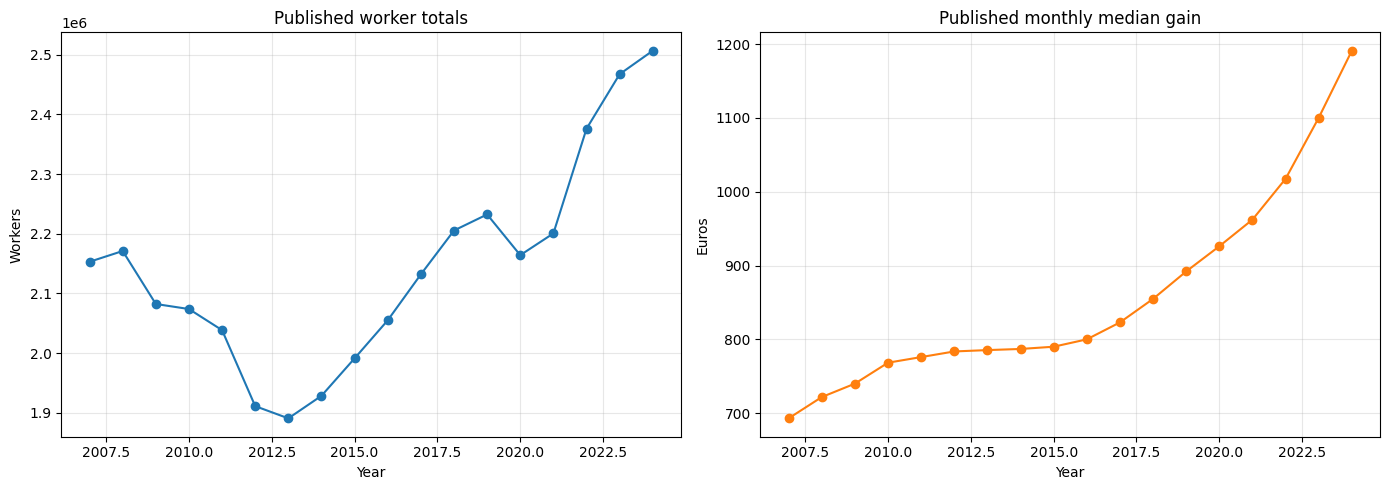

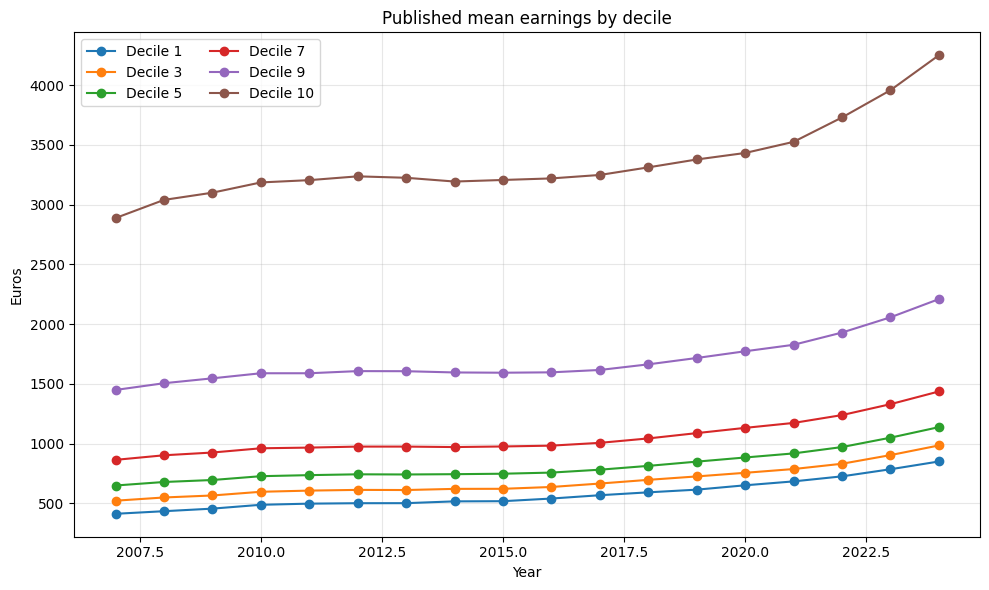

In [6]:
median_series = salary_summaries.query("statistic == 'median_gain'")[["year", "value"]].rename(columns={"value": "median_gain"})
decile_means = salary_summaries.query("statistic == 'mean_gain_by_decile'").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(totals_comparison["year"], totals_comparison["total_workers"], marker="o")
axes[0].set_title("Published worker totals")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Workers")
axes[0].grid(True, alpha=0.3)

axes[1].plot(median_series["year"], median_series["median_gain"], marker="o", color="tab:orange")
axes[1].set_title("Published monthly median gain")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Euros")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "context_totals_and_median.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for decile in [1, 3, 5, 7, 9, 10]:
    series = decile_means.query("decile == @decile").sort_values("year")
    ax.plot(series["year"], series["value"], marker="o", label=f"Decile {decile}")
ax.set_title("Published mean earnings by decile")
ax.set_xlabel("Year")
ax.set_ylabel("Euros")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "context_decile_means.png", dpi=160)
plt.show()

Two points matter here. First, this is a strongly **nominally trending** series, so cross-year comparisons should focus on shape and relative fit, not on unadjusted levels alone. Second, the widening distance between the lower deciles and the top decile is exactly the kind of feature that can make a single smooth family struggle.

## Fit grouped distributions by year

The main fitting step uses the published bracket counts. The equality mass at the minimum wage is excluded from the continuous grouped likelihood because a point mass cannot be represented cleanly by these smooth families.

In [7]:
fit_results = fit_year_models(salary_bins)
fit_results.to_csv(PROCESSED_DIR / "distribution_fit_results.csv", index=False)

winners = model_winners(fit_results)
winners.to_csv(PROCESSED_DIR / "model_winners_by_year.csv", index=False)

display(fit_results.head(12))
display(winners.head(12))

,year,model,n_bins,n_workers_used,nll,aic,bic,chi_square,chi_square_df,chi_square_p_value,converged,message,param_shape,param_scale,param_sigma,param_shape_a,param_shape_c
0,2007,gamma,9,2043004.0,4.091254e+06,8.182512e+06,8.182537e+06,5.361814e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.087730,316.341852,NaN,NaN,NaN
1,2007,lognormal,9,2043004.0,3.847485e+06,7.694974e+06,7.694999e+06,8.364065e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,824.479691,0.536191,NaN,NaN
2,2007,weibull,9,2043004.0,4.287803e+06,8.575611e+06,8.575636e+06,4.971666e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1.557500,1103.741661,NaN,NaN,NaN
3,2007,generalized_gamma,9,2043004.0,3.927257e+06,7.854520e+06,7.854557e+06,1.266393e+06,5,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,0.171264,NaN,23.471443,0.369653
4,2008,gamma,9,2056345.0,4.217439e+06,8.434883e+06,8.434908e+06,4.621965e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.103640,328.905623,NaN,NaN,NaN
5,2008,lognormal,9,2056345.0,3.971373e+06,7.942750e+06,7.942775e+06,8.753049e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,862.048540,0.534760,NaN,NaN
6,2008,weibull,9,2056345.0,4.416263e+06,8.832530e+06,8.832555e+06,4.157867e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1.562501,1154.157650,NaN,NaN,NaN
7,2008,generalized_gamma,9,2056345.0,4.050498e+06,8.101002e+06,8.101040e+06,1.295468e+06,5,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,0.135335,NaN,24.564335,0.363145
8,2009,gamma,9,1952771.0,4.076767e+06,8.153539e+06,8.153564e+06,3.839933e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.149252,334.578261,NaN,NaN,NaN
9,2009,lognormal,9,1952771.0,3.844626e+06,7.689255e+06,7.689280e+06,8.735933e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,891.765600,0.531054,NaN,NaN


,year,winner_bic,winner_aic,bic_value,aic_value
0,2007,lognormal,lognormal,7.694999e+06,7.694974e+06
1,2008,lognormal,lognormal,7.942775e+06,7.942750e+06
2,2009,lognormal,lognormal,7.689280e+06,7.689255e+06
3,2010,lognormal,lognormal,6.638342e+06,6.638317e+06
4,2011,lognormal,lognormal,6.583933e+06,6.583908e+06
5,2012,lognormal,lognormal,6.218751e+06,6.218726e+06
6,2013,lognormal,lognormal,6.153697e+06,6.153672e+06
7,2014,lognormal,lognormal,4.636839e+06,4.636814e+06
8,2015,lognormal,lognormal,4.796904e+06,4.796879e+06
9,2016,lognormal,lognormal,5.032064e+06,5.032039e+06


AIC and BIC should not be read as metaphysical truth. They answer a narrower question: **which candidate family assigns the most likelihood to the published grouped counts, after penalizing complexity?** That is still very useful, because it turns the Gamma claim into a directly testable statement.

## Model competition over time

This section shows whether one family is consistently better or whether the winner changes over time. A changing winner usually means the data shape is not stable enough to justify one universal distributional claim.

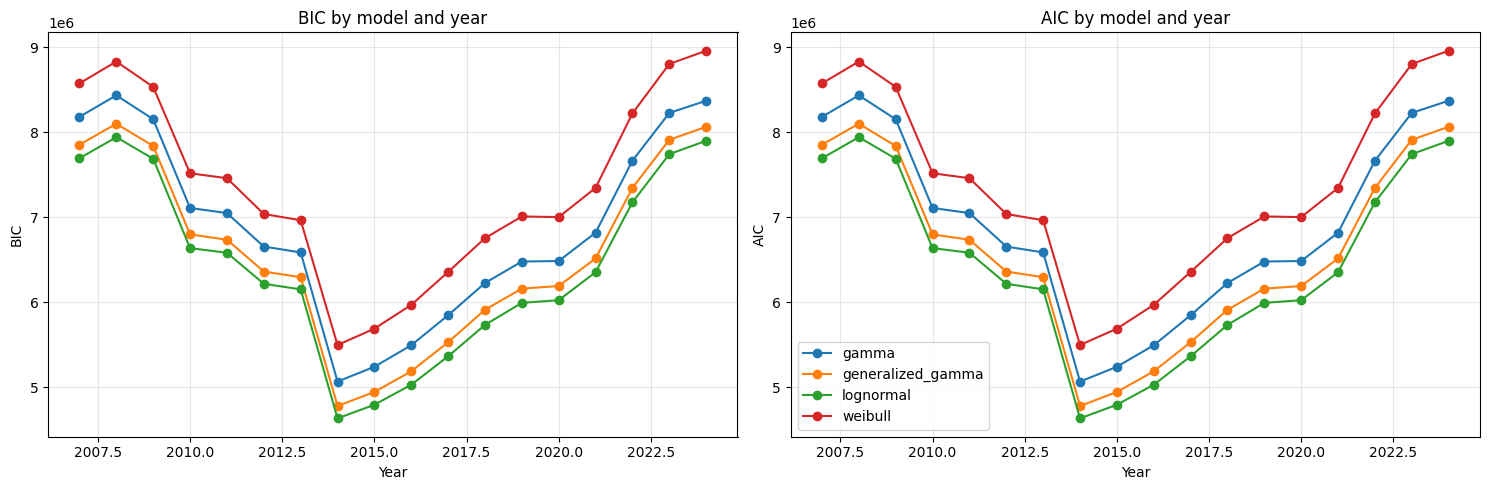

,model,n_years_bic_winner
0,lognormal,18


In [8]:
comparison_plot = fit_results.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name, model_df in comparison_plot.groupby("model"):
    axes[0].plot(model_df["year"], model_df["bic"], marker="o", label=model_name)
    axes[1].plot(model_df["year"], model_df["aic"], marker="o", label=model_name)

axes[0].set_title("BIC by model and year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("BIC")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("AIC by model and year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("AIC")
axes[1].grid(True, alpha=0.3)

axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "aic_bic_model_comparison.png", dpi=160)
plt.show()

winner_counts = winners["winner_bic"].value_counts().rename_axis("model").reset_index(name="n_years_bic_winner")
display(winner_counts)

If Gamma wins rarely, the right conclusion is not that Gamma is useless. The right conclusion is narrower: Gamma may still be a decent approximation for the body of the distribution, but it is not the best full grouped-data summary across years.

## Gamma parameter trends

Even when Gamma is not the overall winner, its parameters can still provide a compact description of how skewness and scale evolve. That is useful if the goal is to understand whether the distribution becomes more compressed or more spread out over time.

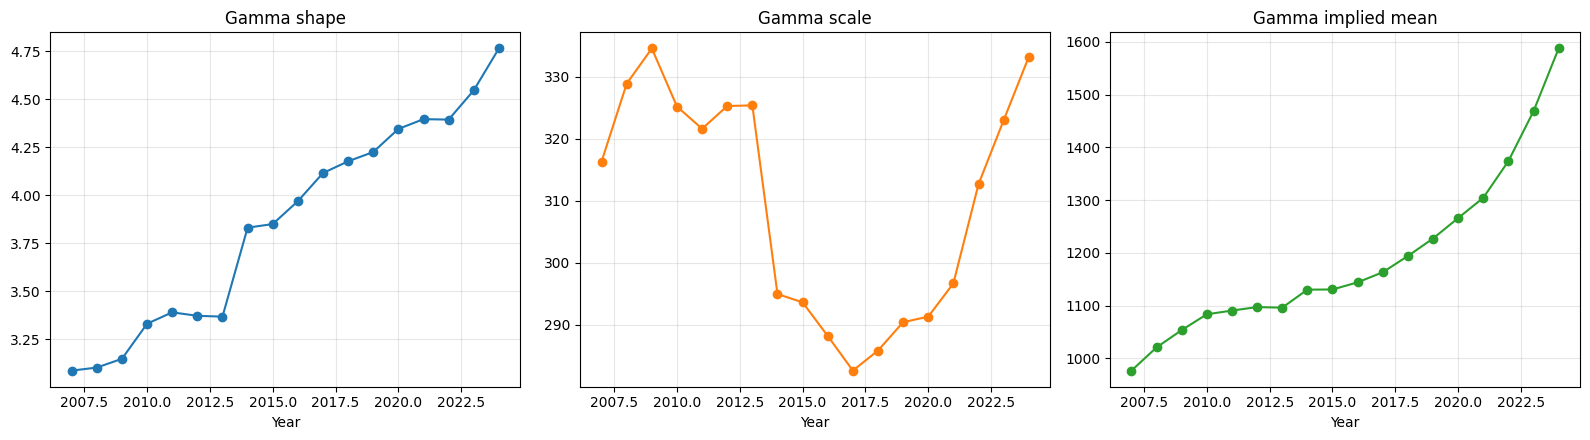

In [9]:
gamma_trend = gamma_parameter_trend(fit_results)
gamma_trend.to_csv(PROCESSED_DIR / "gamma_parameter_trend.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(gamma_trend["year"], gamma_trend["param_shape"], marker="o")
axes[0].set_title("Gamma shape")
axes[0].set_xlabel("Year")
axes[0].grid(True, alpha=0.3)

axes[1].plot(gamma_trend["year"], gamma_trend["param_scale"], marker="o", color="tab:orange")
axes[1].set_title("Gamma scale")
axes[1].set_xlabel("Year")
axes[1].grid(True, alpha=0.3)

axes[2].plot(gamma_trend["year"], gamma_trend["fitted_mean"], marker="o", color="tab:green")
axes[2].set_title("Gamma implied mean")
axes[2].set_xlabel("Year")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "gamma_parameter_trends.png", dpi=160)
plt.show()

The most useful reading is comparative rather than absolute. A rising scale with limited shape movement suggests a general widening in the earnings scale. A collapsing shape would point to stronger skewness. The plot makes those tendencies visible without claiming Gamma is the one true model.

## Histogram-style views of the published distribution

The public source does not provide worker-level microdata, so a literal microdata histogram is not available here. The defensible substitute is a **grouped histogram** built from the published salary brackets: each bar width is the bracket width and each bar area is the worker share in that bracket.

The plots below show the observed grouped histogram together with fitted model densities for three representative years.

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


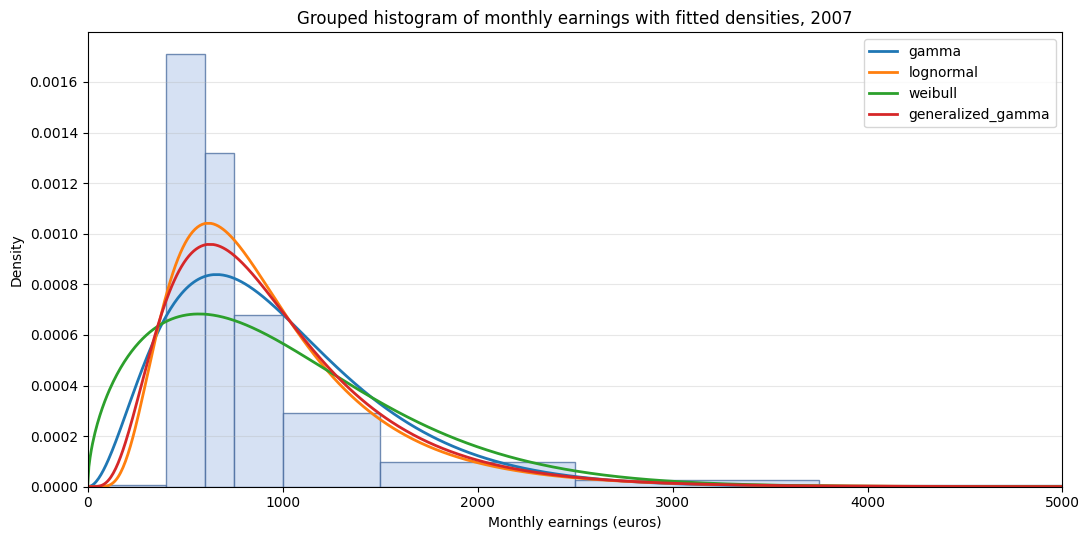

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


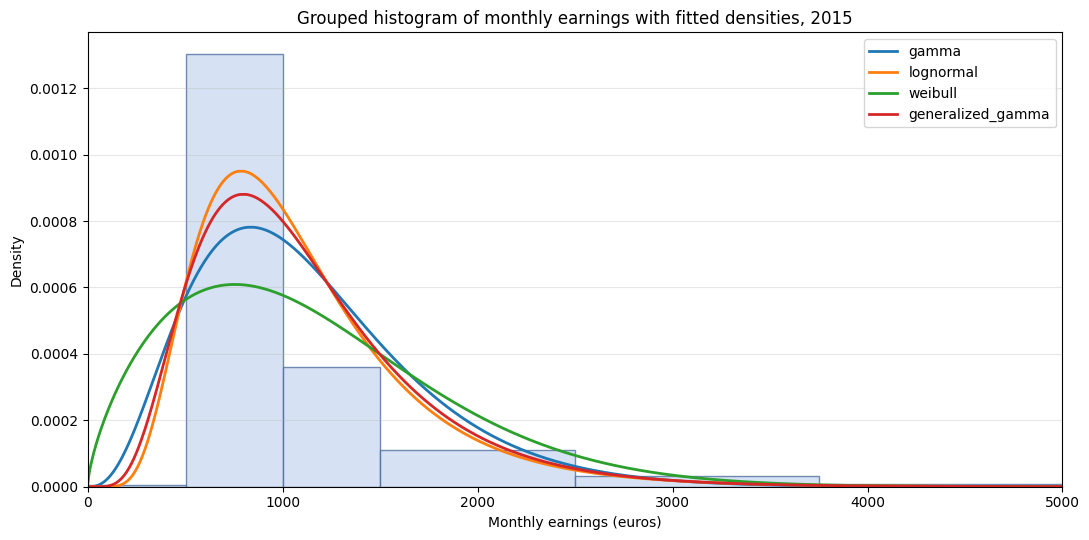

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


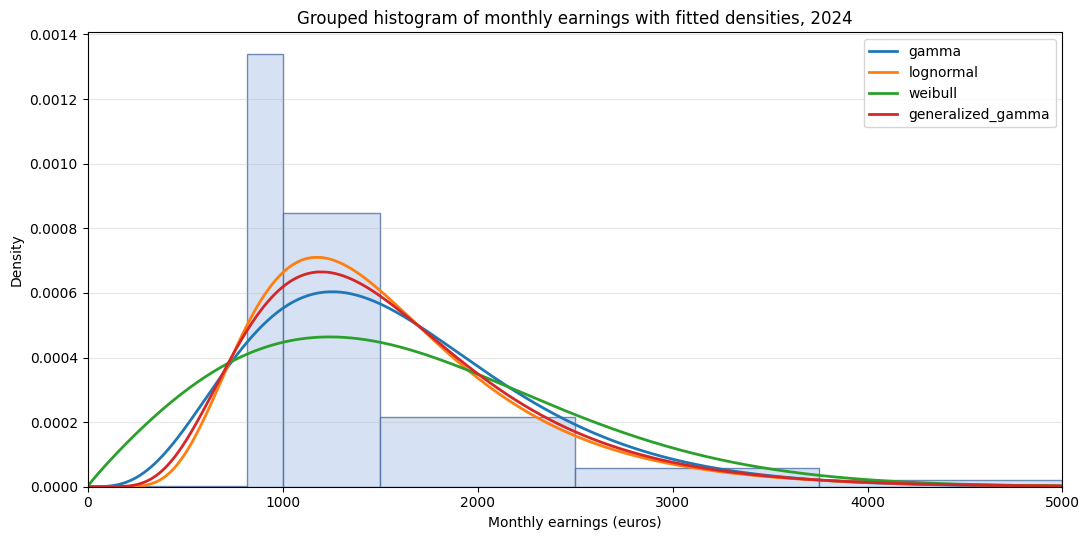

In [10]:
selected_years = [int(salary_bins["year"].min()), int(np.median(sorted(salary_bins["year"].unique()))), int(salary_bins["year"].max())]


def frozen_from_row(row: pd.Series):
    """Build a scipy frozen distribution from a fitted-results row."""
    fit = fit_row_to_object(row)
    if fit.name == "gamma":
        return stats.gamma(a=fit.params["shape"], loc=0.0, scale=fit.params["scale"])
    if fit.name == "lognormal":
        return stats.lognorm(s=fit.params["sigma"], loc=0.0, scale=fit.params["scale"])
    if fit.name == "weibull":
        return stats.weibull_min(c=fit.params["shape"], loc=0.0, scale=fit.params["scale"])
    return stats.gengamma(
        a=fit.params["shape_a"],
        c=fit.params["shape_c"],
        loc=0.0,
        scale=fit.params["scale"],
    )


def plot_grouped_histogram_with_fits(year: int, x_cap: float = 5000.0) -> None:
    """Plot a grouped-data histogram with fitted model density overlays."""
    year_bins = salary_bins.query("year == @year and bin_type != 'exact_minimum_wage'").copy()
    year_bins = year_bins.query("count > 0").sort_values("lower").copy()
    year_bins["plot_upper"] = np.where(np.isfinite(year_bins["upper"]), year_bins["upper"], x_cap)
    year_bins["width"] = year_bins["plot_upper"] - year_bins["lower"]
    year_bins["share"] = year_bins["count"] / year_bins["count"].sum()
    year_bins["density_height"] = year_bins["share"] / year_bins["width"]

    x = np.linspace(0.0, x_cap, 800)
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for row in year_bins.itertuples(index=False):
        ax.bar(
            row.lower,
            row.density_height,
            width=row.width,
            align="edge",
            color="#c9d7f0",
            edgecolor="#45689c",
            alpha=0.75,
        )

    for model_name in ["gamma", "lognormal", "weibull", "generalized_gamma"]:
        result_row = fit_results.query("year == @year and model == @model_name").iloc[0]
        frozen = frozen_from_row(result_row)
        density = np.asarray(frozen.pdf(x), dtype=float)
        density = np.where(np.isfinite(density), density, np.nan)
        density = np.clip(density, 0.0, np.nanpercentile(density[np.isfinite(density)], 99.5) if np.isfinite(density).any() else 1.0)
        ax.plot(x, density, linewidth=2, label=model_name)

    ax.set_title(f"Grouped histogram of monthly earnings with fitted densities, {year}")
    ax.set_xlabel("Monthly earnings (euros)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, x_cap)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"grouped_histogram_with_fits_{year}.png", dpi=160)
    plt.show()


for year in selected_years:
    plot_grouped_histogram_with_fits(year)

These are not synthetic visual extras. They are the main shape plots for grouped public data. If one model systematically overshoots the middle brackets or undershoots the upper tail, it becomes visible here immediately in a way that AIC and BIC alone do not show.

## Bracket-level residual diagnostics

Global information criteria can hide where the misspecification sits. Grouped Pearson residuals show whether models fail mostly near the minimum wage, in the upper middle, or in the top tail.

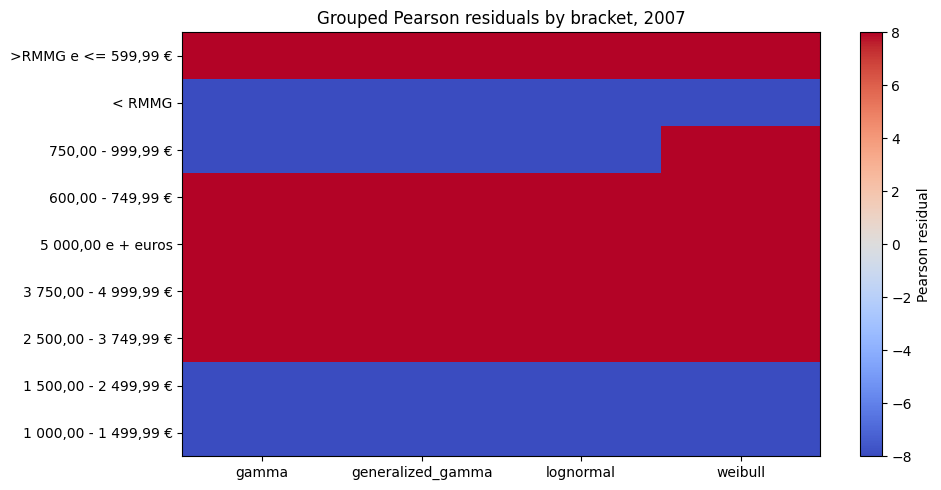

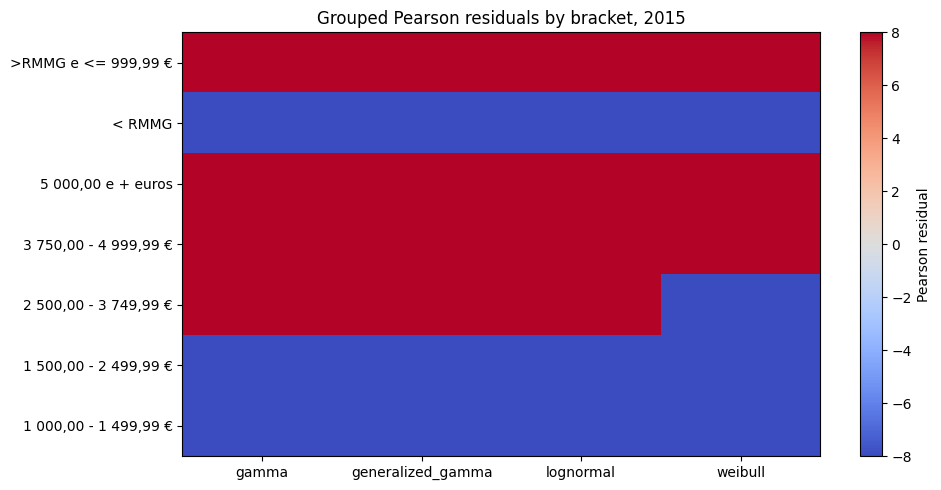

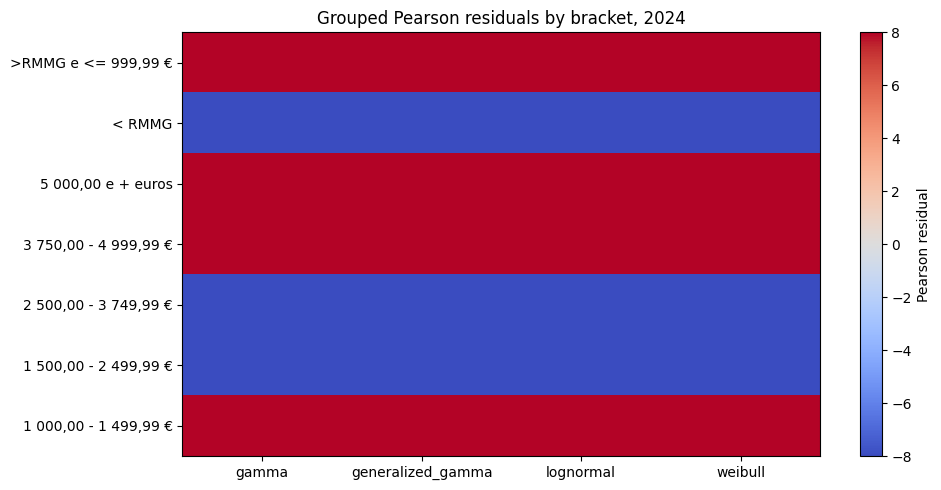

In [11]:
residuals = grouped_residuals(salary_bins, fit_results)
residuals.to_csv(PROCESSED_DIR / "grouped_residuals_by_bin.csv", index=False)

for year in selected_years:
    pivot = (
        residuals.query("year == @year")
        .pivot(index="bin_label", columns="model", values="pearson_residual")
        .sort_index(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    image = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="coolwarm", vmin=-8, vmax=8)
    ax.set_title(f"Grouped Pearson residuals by bracket, {year}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    fig.colorbar(image, ax=ax, label="Pearson residual")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"grouped_residuals_{year}.png", dpi=160)
    plt.show()

A clean residual picture would look like random noise around zero. A systematic block of positive residuals in the upper brackets means the model is underfitting the top tail. A large pattern around the minimum wage usually means institutional wage-setting is breaking the smooth-distribution assumption.

## Observed versus fitted decile means

The grouped brackets drive the likelihood, but the decile means are an external validation layer. A model that wins on AIC/BIC and still misses decile means badly is not a convincing summary of the public distribution.

,year,model,mean_abs_relative_error,max_abs_relative_error,rmse
0,2007,gamma,0.200778,0.373380,270.410022
1,2007,generalized_gamma,0.159404,0.269234,248.015400
2,2007,lognormal,0.137060,0.240427,239.235275
3,2007,weibull,0.250442,0.621863,253.989236
4,2008,gamma,0.202282,0.374977,290.010167
5,2008,generalized_gamma,0.160139,0.269609,267.877117
6,2008,lognormal,0.138232,0.247499,258.035304
7,2008,weibull,0.253014,0.622057,272.384249
8,2009,gamma,0.207431,0.377592,294.605650
9,2009,generalized_gamma,0.165725,0.274735,271.215055


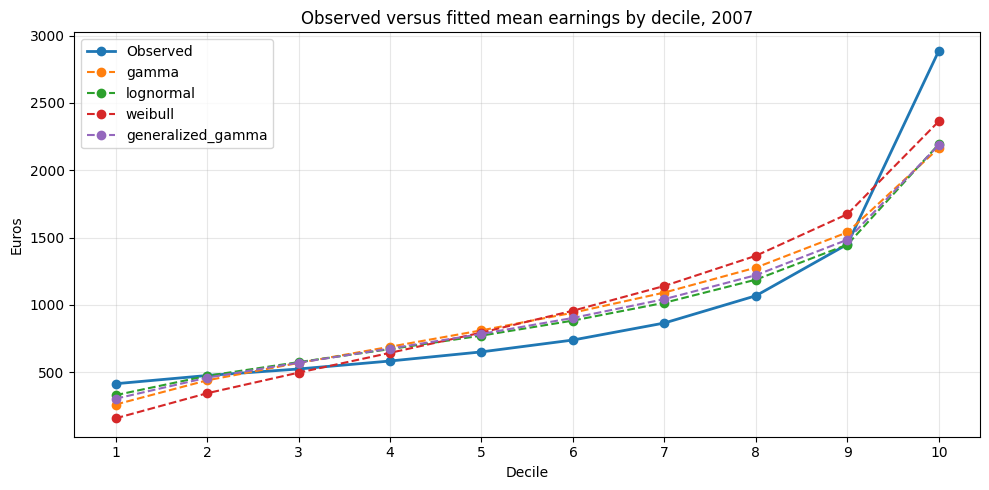

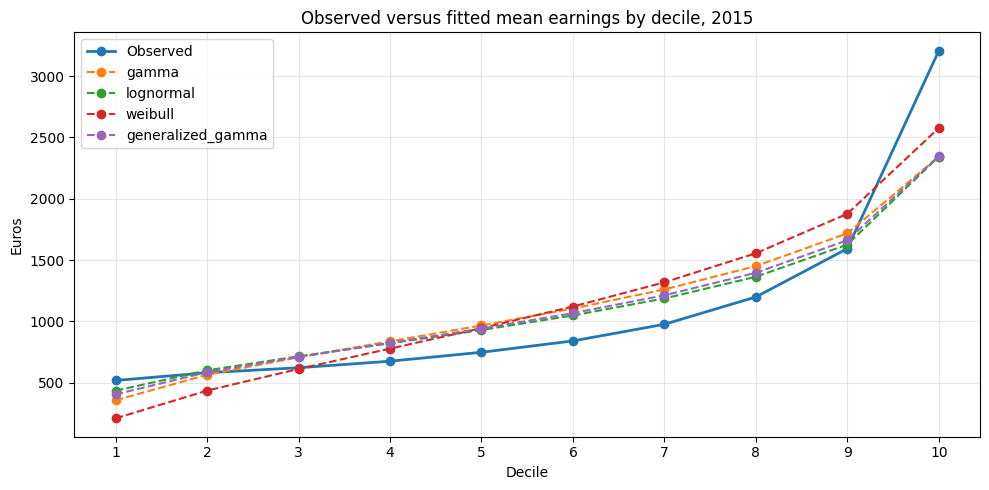

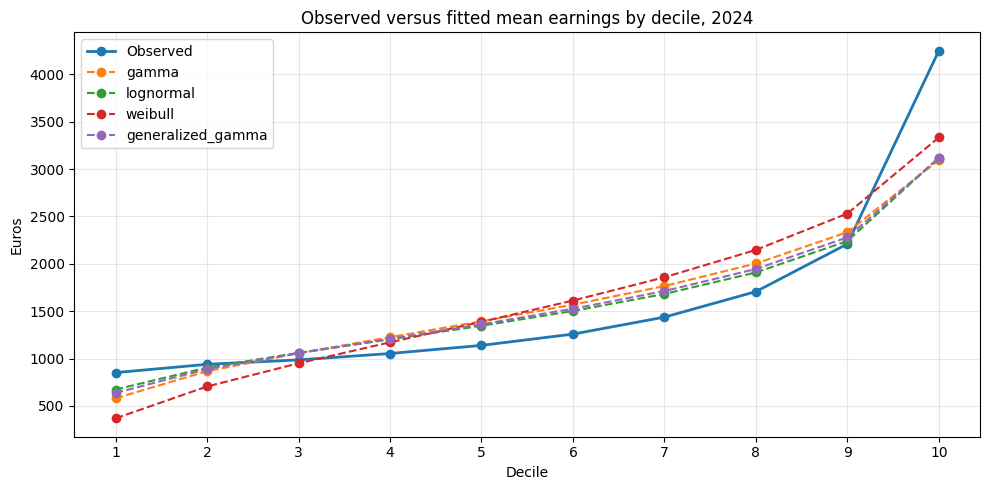

In [12]:
decile_fit = decile_validation(salary_summaries, fit_results)
decile_fit_summary = decile_validation_summary(decile_fit)

decile_fit.to_csv(PROCESSED_DIR / "decile_fit_validation.csv", index=False)
decile_fit_summary.to_csv(PROCESSED_DIR / "decile_fit_validation_summary.csv", index=False)

display(decile_fit_summary.head(12))

for year in selected_years:
    fig, ax = plt.subplots(figsize=(10, 5))
    observed = decile_fit.query("year == @year and model == 'gamma'").sort_values("decile")
    if observed.empty:
        continue
    ax.plot(observed["decile"], observed["observed_mean_gain"], marker="o", linewidth=2, label="Observed")
    for model_name in ["gamma", "lognormal", "weibull", "generalized_gamma"]:
        model_df = decile_fit.query("year == @year and model == @model_name").sort_values("decile")
        if model_df.empty:
            continue
        ax.plot(model_df["decile"], model_df["fitted_mean_gain"], marker="o", linestyle="--", label=model_name)
    ax.set_title(f"Observed versus fitted mean earnings by decile, {year}")
    ax.set_xlabel("Decile")
    ax.set_ylabel("Euros")
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"decile_validation_{year}.png", dpi=160)
    plt.show()

This is the most intuitive validation layer in the notebook. If a model fits the grouped counts but misses the upper-decile means badly, it is likely getting the **shape of the tail** wrong even if the bracket likelihood looks competitive.

## Optional top-tail check: Pareto diagnostic

This is not part of the main AIC/BIC competition. It is a tail-only diagnostic built from the highest salary brackets. The purpose is to see whether the upper tail behaves like something heavier than the main body models suggest.

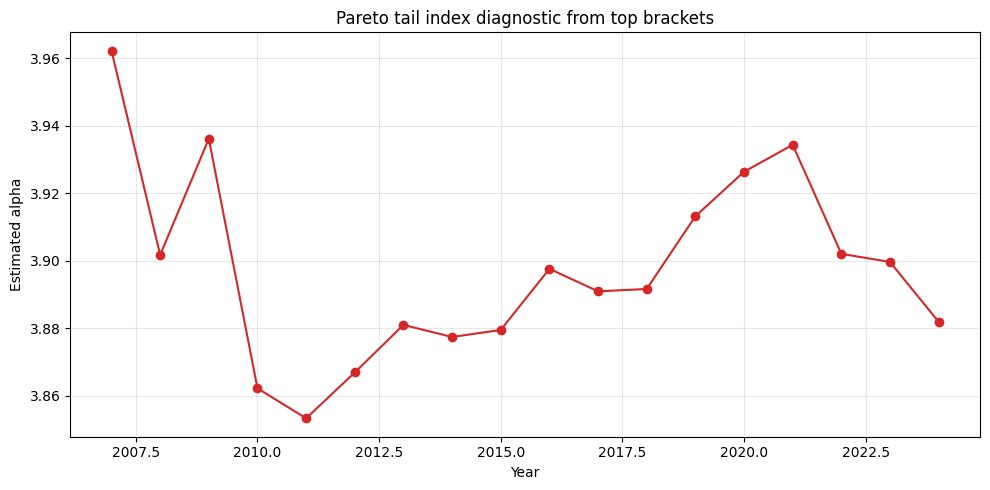

,year,tail_threshold,pareto_alpha,tail_worker_count,tail_worker_share
8,2015,3750.0,3.879508,39553.0,0.019865
9,2016,3750.0,3.897587,41446.0,0.020169
10,2017,3750.0,3.890944,43588.0,0.020445
11,2018,3750.0,3.891629,47387.0,0.021486
12,2019,3750.0,3.913158,50506.0,0.022624
13,2020,3750.0,3.926325,51019.0,0.023575
14,2021,3750.0,3.934304,56368.0,0.025615
15,2022,3750.0,3.902038,70430.0,0.029641
16,2023,3750.0,3.899632,86115.0,0.034898
17,2024,3750.0,3.881895,106835.0,0.042616


In [13]:
tail_diagnostics = pareto_tail_diagnostics(salary_bins)
tail_diagnostics.to_csv(PROCESSED_DIR / "pareto_tail_diagnostics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tail_diagnostics["year"], tail_diagnostics["pareto_alpha"], marker="o", color="tab:red")
ax.set_title("Pareto tail index diagnostic from top brackets")
ax.set_xlabel("Year")
ax.set_ylabel("Estimated alpha")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pareto_tail_alpha.png", dpi=160)
plt.show()

display(tail_diagnostics.tail(10))

Lower Pareto alpha means a heavier top tail. This diagnostic should be read cautiously because it is built from grouped top bins, not individual top incomes. Still, it adds useful context when smooth full-distribution models systematically miss the last brackets.

## Optional microdata branch

Public reproducibility should not depend on restricted microdata. Still, if a local anonymized file exists under `data/private/`, the package can fit a microdata branch for comparison. If no file exists, the notebook should skip cleanly.

In [14]:
microdata_fit = optional_microdata_fit(PRIVATE_DIR)
if microdata_fit.empty:
    print("No local anonymized microdata file found. Public grouped-data pipeline remains fully reproducible.")
else:
    microdata_fit.to_csv(PROCESSED_DIR / "optional_microdata_fit.csv", index=False)
    display(microdata_fit.head())

No local anonymized microdata file found. Public grouped-data pipeline remains fully reproducible.


This branch is deliberately optional. The public notebook should stand on its own, and the microdata path is only there for a future stronger replication if anonymized access becomes available.

## Synthesis

The final section compresses the notebook into a few empirical answers:

- what years the public grouped data really cover;
- which model wins most often;
- how Gamma behaves relative to alternatives;
- whether the residuals and decile checks show systematic misspecification.

In [15]:
winner_share = winner_counts.copy()
gamma_decile_summary = decile_fit_summary.query("model == 'gamma'").copy()

summary_table = pd.DataFrame(
    [
        {"finding": "Public grouped-analysis window", "value": f"{int(salary_bins['year'].min())}-{int(salary_bins['year'].max())}"},
        {"finding": "Number of grouped-analysis years", "value": int(salary_bins["year"].nunique())},
        {"finding": "Most frequent BIC winner", "value": winner_share.sort_values("n_years_bic_winner", ascending=False).iloc[0]["model"]},
        {"finding": "Gamma mean absolute decile error (median across years)", "value": round(float(gamma_decile_summary["mean_abs_relative_error"].median()), 4)},
        {"finding": "Largest total-count mismatch", "value": int(abs(totals_comparison["difference"]).max())},
    ]
)
summary_table.to_csv(PROCESSED_DIR / "notebook_summary_table.csv", index=False)
display(summary_table)

conclusion_lines = [
    f"The grouped public salary-distribution analysis is reproducibly available for {int(salary_bins['year'].min())}-{int(salary_bins['year'].max())}, not for the full 1999-2024 span.",
    f"The most frequent BIC winner is {winner_share.sort_values('n_years_bic_winner', ascending=False).iloc[0]['model']}.",
    "Gamma remains a useful benchmark because its parameters are interpretable, but it should be defended as an approximation, not assumed as the data-generating law.",
    "Residuals near the minimum wage and in the top brackets are the main places to look when the smooth models disagree with the published tables.",
]
for line in conclusion_lines:
    print(f"- {line}")

,finding,value
0,Public grouped-analysis window,2007-2024
1,Number of grouped-analysis years,18
2,Most frequent BIC winner,lognormal
3,Gamma mean absolute decile error (median acros...,0.2013
4,Largest total-count mismatch,0


- The grouped public salary-distribution analysis is reproducibly available for 2007-2024, not for the full 1999-2024 span.
- The most frequent BIC winner is lognormal.
- Gamma remains a useful benchmark because its parameters are interpretable, but it should be defended as an approximation, not assumed as the data-generating law.
- Residuals near the minimum wage and in the top brackets are the main places to look when the smooth models disagree with the published tables.


The defensible conclusion is now narrower and stronger. The notebook no longer says "Portugal salaries are Gamma distributed." It now shows, year by year, whether Gamma is competitive against alternatives, where it fails, and how much of that failure comes from minimum-wage mass or from the top tail.